In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [2]:

# =========================
# Load data
# =========================

train = np.load("./data/processed/dataset_train_shortened.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]

full = np.load("./data/processed/dataset_full.npz", allow_pickle=True)
X_full = full["X"]
K0_full = full["K0"]

print("X_train shape:", X_train.shape)
print("X_full shape :", X_full.shape)

#

X_train shape: (47222, 30)
X_full shape : (6205696, 30)


In [4]:
#=========================
# Helper functions
# =========================

def run_raw_model(model, X_train, y_train, X_full):
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)

    if hasattr(model, "predict_proba"):
        P_A = model.predict_proba(X_full)[:, 1]
    else:
        scores = model.decision_function(X_full)
        P_A = 1.0 / (1.0 + np.exp(-scores))

    return train_acc, P_A


def mean_and_susceptibility_vs_K0(P_A, K0_full):
    df = pd.DataFrame({
        "K0": K0_full,
        "P_C": 1.0 - P_A
    })

    grouped = df.groupby("K0")["P_C"]
    mean_P_C = grouped.mean()
    chi_P_C = grouped.var()

    return mean_P_C, chi_P_C


def extract_k0_crit(chi_series):
    idx = np.argmax(chi_series.values)
    return chi_series.index.values[idx]


def plot_results(mean_P_C, chi_P_C, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # ⟨Pr(C)⟩
    ax1.plot(mean_P_C.index, mean_P_C.values, marker="o")
    ax1.set_xlabel(r"$\kappa_0$")
    ax1.set_ylabel(r"$\langle \mathrm{Pr}(C) \rangle$")
    ax1.set_title(title)
    ax1.grid(True)

    # susceptibility χ
    ax2.plot(chi_P_C.index, chi_P_C.values, marker="o")
    ax2.set_xlabel(r"$\kappa_0$")
    ax2.set_ylabel(r"$\chi$")
    ax2.set_title("Susceptibility")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()




=== RAW Decision Tree ===
train accuracy = 1.00000
k0_crit        = 4.7800
time           = 0.36 s


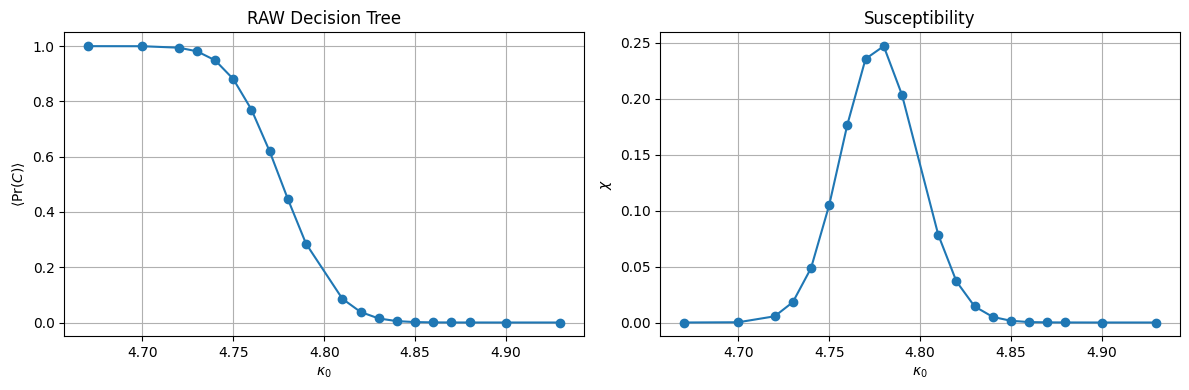

In [5]:

# =========================
# RAW Decision Tree
# =========================

print("\n=== RAW Decision Tree ===")

dt = DecisionTreeClassifier()

t0 = time.perf_counter()
acc_dt, P_A_dt = run_raw_model(dt, X_train, y_train, X_full)
elapsed = time.perf_counter() - t0

mean_P_C_dt, chi_dt = mean_and_susceptibility_vs_K0(P_A_dt, K0_full)
k0_crit_dt = extract_k0_crit(chi_dt)

print(f"train accuracy = {acc_dt:.5f}")
print(f"k0_crit        = {k0_crit_dt:.4f}")
print(f"time           = {elapsed:.2f} s")

plot_results(mean_P_C_dt, chi_dt, "RAW Decision Tree")



=== RAW Random Forest ===
train accuracy = 1.00000
k0_crit        = 4.7700
time           = 8.62 s


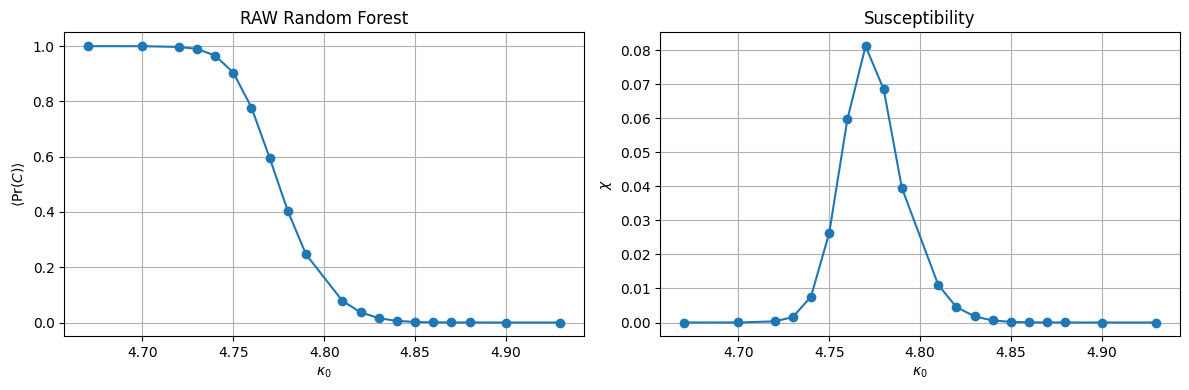

In [6]:

# =========================
# RAW Random Forest
# =========================

print("\n=== RAW Random Forest ===")

rf = RandomForestClassifier()

t0 = time.perf_counter()
acc_rf, P_A_rf = run_raw_model(rf, X_train, y_train, X_full)
elapsed = time.perf_counter() - t0

mean_P_C_rf, chi_rf = mean_and_susceptibility_vs_K0(P_A_rf, K0_full)
k0_crit_rf = extract_k0_crit(chi_rf)

print(f"train accuracy = {acc_rf:.5f}")
print(f"k0_crit        = {k0_crit_rf:.4f}")
print(f"time           = {elapsed:.2f} s")

plot_results(mean_P_C_rf, chi_rf, "RAW Random Forest")